## 4.もっと推定を


### 4.1 ユーロ硬貨問題

ベルギーの１ユーロ硬貨を２５０回指で弾いて回してみたところ、表が140回、裏が１１０回出た。
硬貨は釣り合いが取れなくて偏っているか。


尤度関数

$ L(p) = p^{140}(1-p)^{110} $

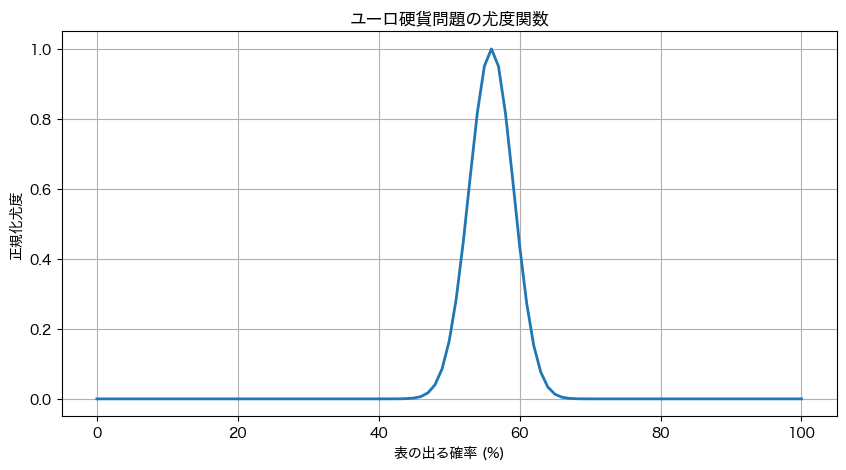

最大尤度仮説: H56
表の出る確率 = 56%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# データ
# -----------------------------
heads = 140
tails = 110

# 仮説 Hx
x = np.arange(0, 101)
p = x / 100

# -----------------------------
# 尤度
# -----------------------------
likelihood = np.zeros_like(p, dtype=float)

for i, prob in enumerate(p):
    if prob == 0:
        likelihood[i] = 1.0 if heads == 0 else 0.0
    elif prob == 1:
        likelihood[i] = 1.0 if tails == 0 else 0.0
    else:
        likelihood[i] = prob**heads * (1-prob)**tails

# 最大値で正規化
likelihood /= likelihood.max()

# -----------------------------
# グラフ
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(x, likelihood, lw=2)
plt.xlabel("表の出る確率 (%)")
plt.ylabel("正規化尤度")
plt.title("ユーロ硬貨問題の尤度関数")
plt.grid(True)
plt.show()

# 最大尤度仮説
best_x = x[np.argmax(likelihood)]

print(f"最大尤度仮説: H{best_x}")
print(f"表の出る確率 = {best_x}%")

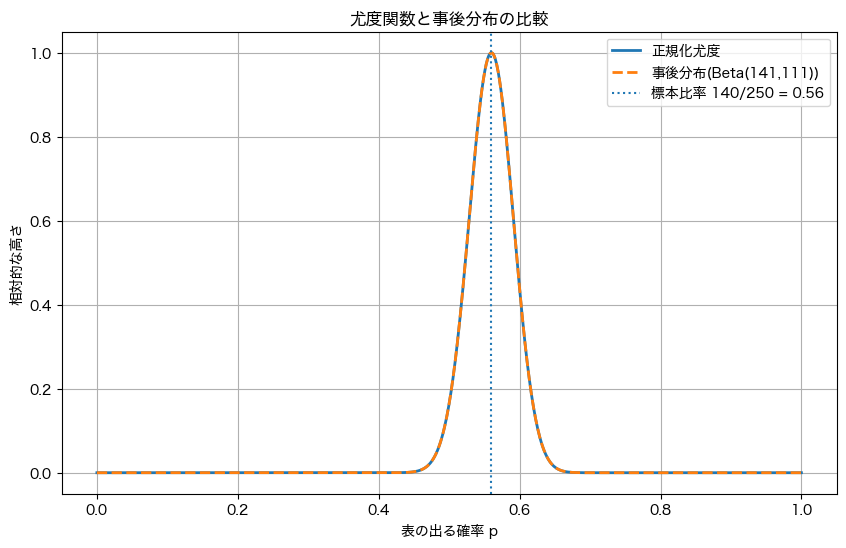

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 日本語フォント
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# データ
heads = 140
tails = 110

# p の連続値
p = np.linspace(0, 1, 1000)

# -------------------
# 尤度
# -------------------
likelihood = p**heads * (1-p)**tails

# 最大値で正規化
likelihood /= likelihood.max()

# -------------------
# 事後分布
# -------------------
posterior = beta.pdf(p, heads+1, tails+1)

# 最大値で正規化
posterior_scaled = posterior / posterior.max()

# -------------------
# グラフ
# -------------------
plt.figure(figsize=(10,6))

plt.plot(
    p,
    likelihood,
    label="正規化尤度",
    linewidth=2
)

plt.plot(
    p,
    posterior_scaled,
    "--",
    label="事後分布(Beta(141,111))",
    linewidth=2
)

plt.axvline(
    heads/(heads+tails),
    linestyle=":",
    label="標本比率 140/250 = 0.56"
)

plt.xlabel("表の出る確率 p")
plt.ylabel("相対的な高さ")
plt.title("尤度関数と事後分布の比較")
plt.grid(True)
plt.legend()

plt.show()

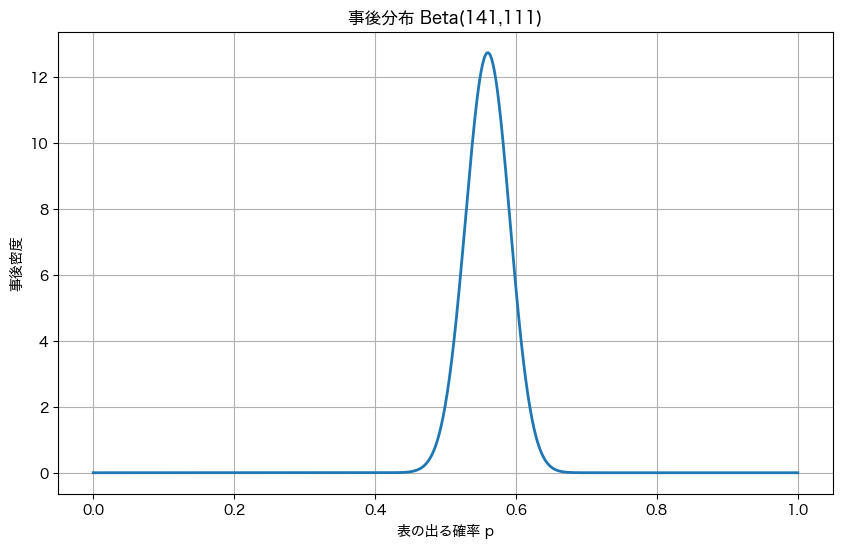

In [7]:
posterior = beta.pdf(p, 141, 111)

plt.figure(figsize=(10,6))
plt.plot(p, posterior, linewidth=2)

plt.xlabel("表の出る確率 p")
plt.ylabel("事後密度")
plt.title("事後分布 Beta(141,111)")
plt.grid(True)

plt.show()